In [1]:
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt
import glob
import matplotlib
%matplotlib inline

In [2]:
#define focusing area
[min_lon, max_lon, min_lat, max_lat]=[100.,150.,10.,50.]
[min_lon_EA, max_lon_EA, min_lat_EA, max_lat_EA]=[100.,150.,12.,48.]
[min_lon_local, max_lon_local, min_lat_local, max_lat_local]=[114.,130.,18.,30.]
[min_lon_tw, max_lon_tw, min_lat_tw, max_lat_tw]=[118,126,22,26]
[min_lon_ish, max_lon_ish, min_lat_ish, max_lat_ish]=[122,126,22,26]

slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]

In [3]:
m='TaiESM1'
sceDict={'historical':[[2000,2010],'2001-01-01','2010-12-31'],
         'ssp585':[[2085,],'2085-01-01','2094-12-31']}

dateList={}
#load EAR5 dataframe
a=pd.read_csv('../data/cold_season_weather_regimes_with_idx.csv',header=0,parse_dates=[0])
dateList['ERA5']=a[(a.prRatio<=0.3)&(a.meanWS>=4.0)&(a.meanWS<=12.0)&(a.meanWD>=40)&(a.meanWD<=180)].date.values

for sce in sceDict.keys():
    if sce=='historical':
        a=pd.read_csv('../data/cold_season_%s_%s.indices.csv'%(m,sce),header=0,parse_dates=[0])
    else:    
        a=pd.read_csv('../data/cold_season_%s_%s_%04d0101-%04d1231.indices.csv'%(m,sce,sceDict[sce][0][0],sceDict[sce][0][0]+9),header=0,parse_dates=[0])
    dateList[sce]=a[(a.prRatio<=0.3)&(a.meanWS>=4.0)&(a.meanWS<=12.0)&(a.meanWD>=40)&(a.meanWD<=180)].date.values
    


In [4]:
dsDict={}
#get ERA5 dataset
dsDict['ERA5']=xr.open_mfdataset(['../data/regridded_%04d.nc'%yr for yr in range(2001,2011)]).sel(time=dateList['ERA5'])

KeyError: "not all values found in index 'time'"

In [6]:
dsDict['ERA5']

KeyError: 'ERA5'

In [5]:
#get model dataset
dataDir='/data/mileshsieh/CMIP6'

template='%s/%s/%s/atmos/day/r1i1p1f1/%s_day_%s_%s_r1i1p1f1_gn_%04d0101-*.nc'
varList=['psl','ua','va','pr']
sce='historical'
p_selected=1000

for sce in sceDict.keys():
    fList=[]
    for yr_start in sceDict[sce][0]:
        #open multiple files
        fList=fList+[glob.glob(template%(dataDir,m,sce,var,m,sce,yr_start))[0] for var in varList]

    ds_model=xr.open_mfdataset(fList).sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon),
                                            time=slice(sceDict[sce][1], sceDict[sce][2]),plev=p_selected*100)
    ds_model=ds_model.rename({'ua':'u','va':'v'})
    ds_model['msl']=ds_model['psl']/100
    ds_model['precipitation']=ds_model.pr*3600
    datetimeindex = ds_model.indexes['time'].to_datetimeindex()
    ds_model['time'] = datetimeindex
    ds_model.coords['time'] = ds_model.time.dt.floor('1D')
    dsDict[sce]=ds_model.sel(time=dateList[sce])

/tmp/ipykernel_205028/392447687.py:20: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  datetimeindex = ds_model.indexes['time'].to_datetimeindex()


KeyError: "not all values found in index 'time'"

In [8]:
sce

'historical'

ERA5 780
historical 619
ssp585 671


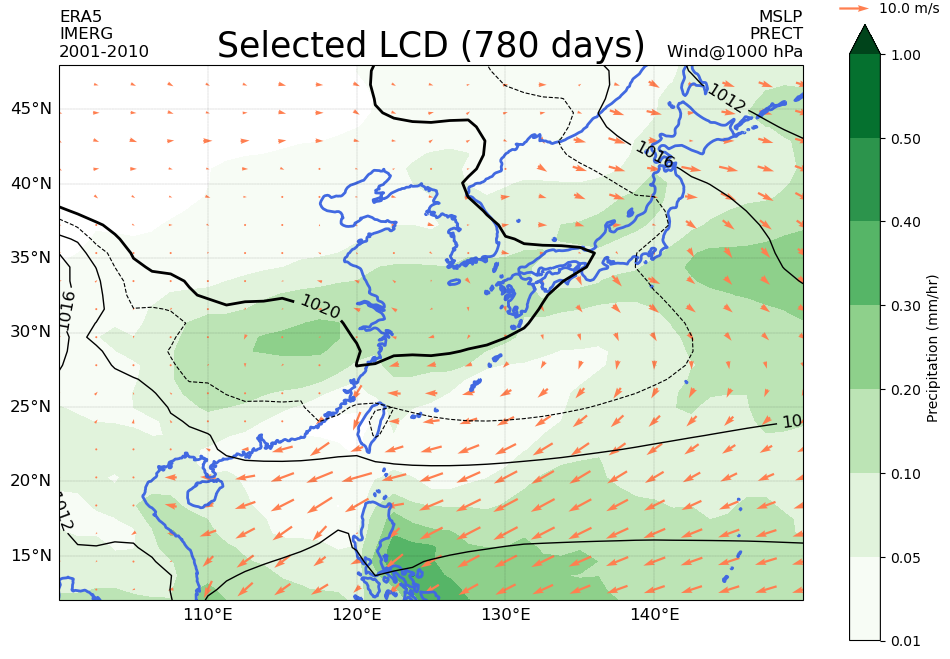

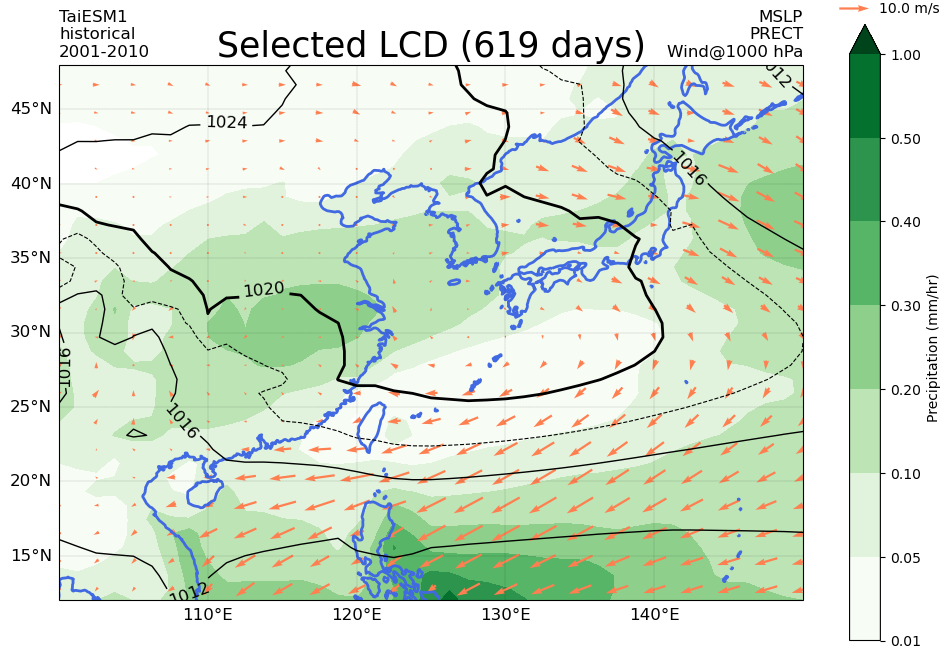

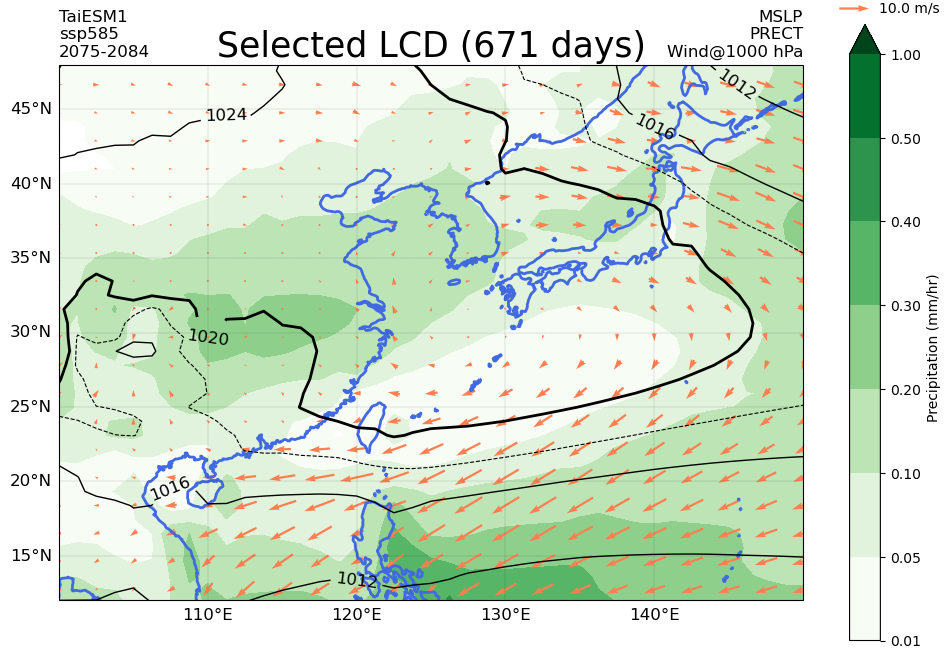

In [12]:
# plot LCD composite of East Asia weather map in ERA5 and models
for lbl in ['ERA5','historical','ssp585']:
    nday=dsDict[lbl].time.size
    print(lbl,nday)
    if lbl!='ERA5':
        title=m+'_'+lbl
    else:
        title='ERA5'
    ds_plot=dsDict[lbl].mean(dim='time')
    titleStr='Selected LCD (%d days)'%nday
    resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
    # Defining the figure
    fig = plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    # Axes with Cartopy projection
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    # and extent
    #ax.set_extent([min_lon_local, max_lon_local, min_lat_local, max_lat_local], ccrs.PlateCarree())
    ax.set_extent([min_lon_EA, max_lon_EA, min_lat_EA, max_lat_EA], ccrs.PlateCarree())

    # Plotting using Matplotlib the mean current
    cs_p = ds_plot['precipitation'].plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.2,0.3,0.4,0.5,1.0],\
                                                  extend='max',cmap='Greens',transform=ccrs.PlateCarree(),\
                                                  cbar_kwargs=dict(label='Precipitation (mm/hr)'))
    #cs_p2 = prect.plot.contour(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],cmap='hot_r',linewidths=1.2,transform=ccrs.PlateCarree())
    cs = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
    cs2 = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=[1018,],
                      colors='k',  
                      linestyles=['--',],linewidths=[0.8,])
    q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='u', v='v', transform=ccrs.PlateCarree(),
                        scale=250,color='coral',width=0.003,add_guide=False)

    ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
    #ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
    #q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
    ax.coastlines(resolution='50m',linewidth=2.0,color='royalblue')
    # Plot lat/lon grid 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12} 

    #ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
    #    [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
    #    lw=2.5,color='cyan',transform=ccrs.PlateCarree())
    #ax.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
    #    [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
    #  lw=2.5,ls='--',color='r',transform=ccrs.PlateCarree())

    ax.set_title(titleStr,fontsize=25)
    if lbl=='ERA5':
        ax.set_title('ERA5\nIMERG\n2001-2010',fontsize=12,loc='left')
    else:
        ax.set_title('%s\n%s\n%s-%s'%(m,lbl,sceDict[lbl][1][:4],sceDict[lbl][2][:4]),fontsize=12,loc='left')
    ax.set_title('MSLP\nPRECT\nWind@1000 hPa',fontsize=12,loc='right')
    #ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
    #ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
    # Vector options declaration
    veclenght = 10
    maxstr = '%3.1f m/s' % veclenght
    plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)
    #plt.savefig('../figures/weatherMap_local.%s.ERA5.png'%r,dpi=200)
    plt.savefig('../figures/weatherMap.selectedLCD.%s.png'%title,dpi=200)

In [11]:
sce='historical'
sceDict[sce][1][:4],sceDict[sce][2][:4]

('2001', '2010')